# Charged Black Holes in Entangled Relativity

## Arnaud Crepinge

### Simple figures

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import brentq

# Font for plotting

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

## I - Horizons

/tmp/ipykernel_17647/487791932.py:4: RuntimeWarning: invalid value encountered in sqrt
  disc = np.sqrt(1 - q**2)
/tmp/ipykernel_17647/487791932.py:20: RuntimeWarning: invalid value encountered in power
  rhop = rp_ER * (1 - rm_ER / rp_ER)**(1/13)
/tmp/ipykernel_17647/487791932.py:21: RuntimeWarning: invalid value encountered in divide
  rhom = rm_ER * (1 - rm_ER / rm_ER)**(1/13)


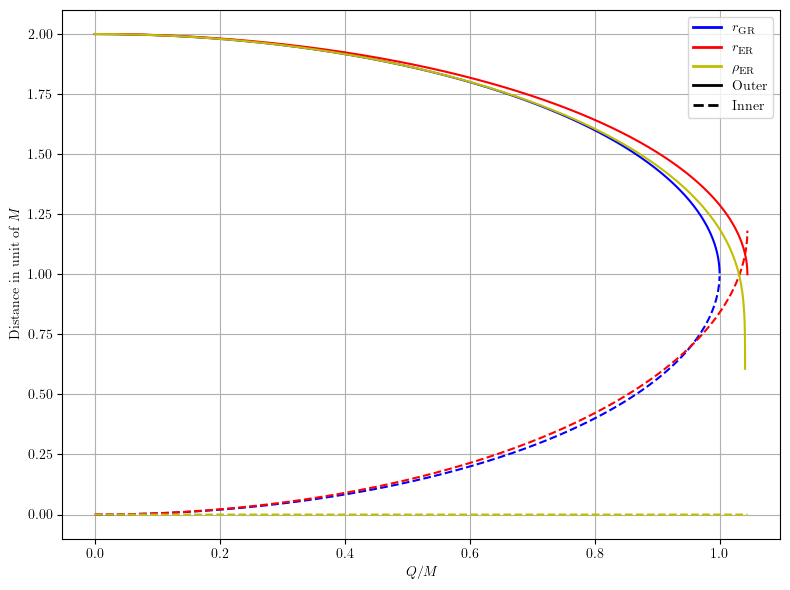

In [2]:
# Horizons in GR

def rpm_GR(q):
    disc = np.sqrt(1 - q**2)
    return 1 + disc, 1 - disc

# Horizons in ER

def rpm_ER(q):
    disc = np.sqrt(1 - (11/12) * q**2)
    return 1 + disc, (13/11) * (1 - disc)

plt.figure(figsize=(8, 6))

q = np.linspace(0,np.sqrt(12/11),10000)

rp_GR, rm_GR = rpm_GR(q)
rp_ER, rm_ER = rpm_ER(q)

rhop = rp_ER * (1 - rm_ER / rp_ER)**(1/13)
rhom = rm_ER * (1 - rm_ER / rm_ER)**(1/13)

plt.plot(q, rp_GR, 'b-')
plt.plot(q, rm_GR, 'b--')
plt.plot(q, rp_ER, 'r-')
plt.plot(q, rm_ER, 'r--')
plt.plot(q, rhop, 'y-')
plt.plot(q, rhom, 'y--')

plt.grid()

legend_elements = [
    Line2D([0], [0], color='b', lw=2, label=r'$r_\mathrm{GR}$'),
    Line2D([0], [0], color='r', lw=2, label=r'$r_\mathrm{ER}$'),
    Line2D([0], [0], color='y', lw=2, label=r'$\rho_\mathrm{ER}$'),
    Line2D([0], [0], color='k', lw=2, linestyle='-',  label='Outer'),
    Line2D([0], [0], color='k', lw=2, linestyle='--', label='Inner')
]

plt.legend(handles=legend_elements)

plt.xlabel(r"$Q/M$")
plt.ylabel(r"Distance in unit of $M$")

plt.tight_layout()
plt.savefig("images/Horizons.png", dpi=150, bbox_inches='tight')

## II - Areal Radius

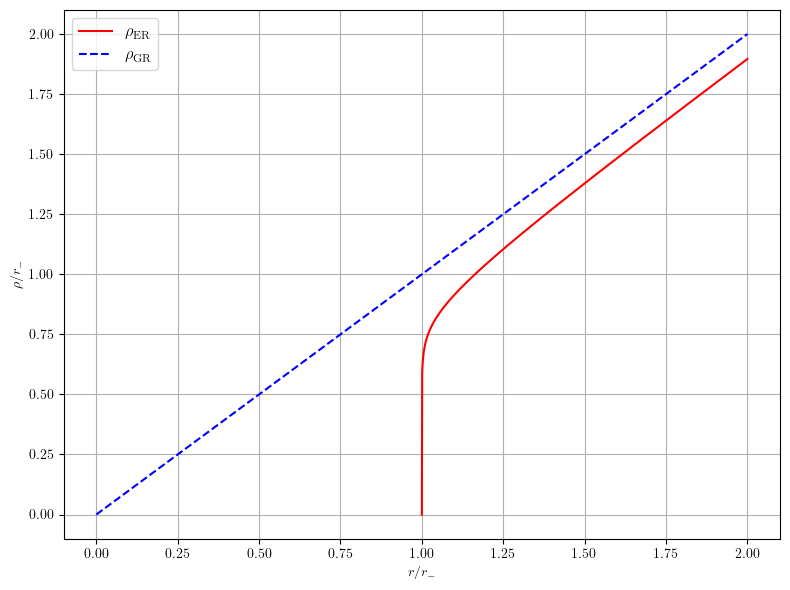

In [3]:
plt.figure(figsize=(8, 6))

r = np.linspace(0,2,1000)
r_ER = np.linspace(1,2,1000)
rho = r_ER * (1 - 1/r_ER)**(1/13)

plt.plot(r_ER, rho, "r-", label=r'$\rho_\mathrm{ER}$')
plt.plot(r, r, 'b--', label=r'$\rho_\mathrm{GR}$')

plt.grid()
plt.xlabel(r'$r/r_-$')
plt.ylabel(r'$\rho / r_-$')
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig("images/rho.png", dpi=150, bbox_inches='tight')

/tmp/ipykernel_17647/1160911947.py:5: RuntimeWarning: divide by zero encountered in divide
  f1 = (1 - rp/r)
/tmp/ipykernel_17647/1160911947.py:6: RuntimeWarning: invalid value encountered in divide
  f2 = (1 - rm/r)**(11/13)


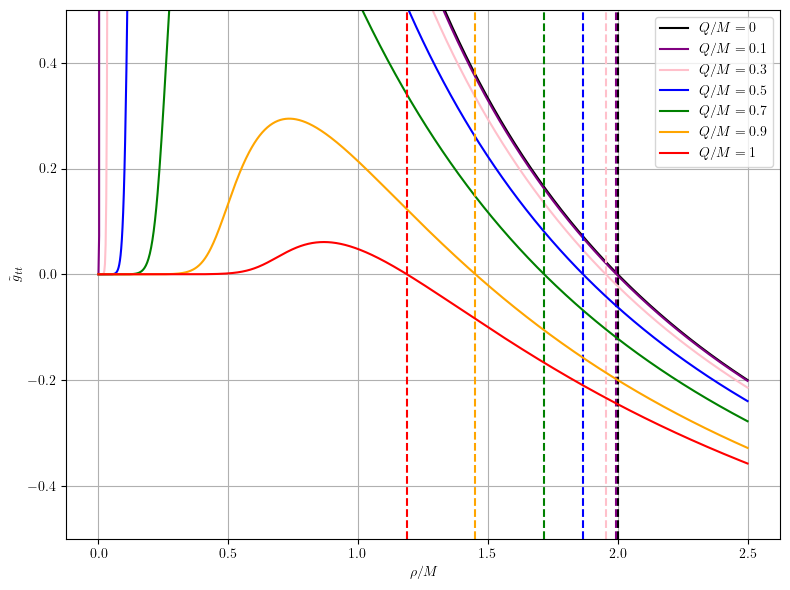

In [4]:
# Checks that the horizon in rho is rho(r_+)

def gtt(r, Q):
    rp, rm = rpm_ER(Q)
    f1 = (1 - rp/r)
    f2 = (1 - rm/r)**(11/13)
    return - f1 * f2

def rho_ER(r, Q):
    _, rm = rpm_ER(Q)
    return r * (1 - rm / r)**(1/13)

def r_coord(rho, Q):
    rp, rm = rpm_ER(Q)
    if np.isclose(Q, 0):
        return rho
    if np.isclose(rho, 0):
        return rm
    return brentq(lambda x: rho_ER(x, Q) - rho, rm, rho + 2*rp)

plt.figure(figsize=(8, 6))

rho_array = np.linspace(0, 2.5, 1000)

cases = [(0, "black"),
        (0.1, "purple"),
        (0.3, "pink"),
        (0.5, "blue"),
        (0.7, "green"),
        (0.9, "orange"),
        (1, "red")]

bound = 0.5

for q, c in cases:
    r_array = np.array([r_coord(rho, q) for rho in rho_array])
    g_tt = gtt(r_array, q)
    rp, _ = rpm_ER(q)
    plt.plot(rho_array, g_tt, label=rf"$Q/M = {q}$", color=c)
    plt.plot([rho_ER(rp, q), rho_ER(rp, q)],[-bound, bound], color=c, linestyle='--')

plt.xlabel(r"$\rho / M$")
plt.ylabel(r"$\tilde g_{tt}$")
plt.ylim(-bound,bound)


plt.grid()
plt.legend()

plt.tight_layout()
plt.savefig("images/gtt.png", dpi=150, bbox_inches='tight')

/tmp/ipykernel_17647/1160911947.py:5: RuntimeWarning: divide by zero encountered in divide
  f1 = (1 - rp/r)
/tmp/ipykernel_17647/1160911947.py:6: RuntimeWarning: invalid value encountered in divide
  f2 = (1 - rm/r)**(11/13)


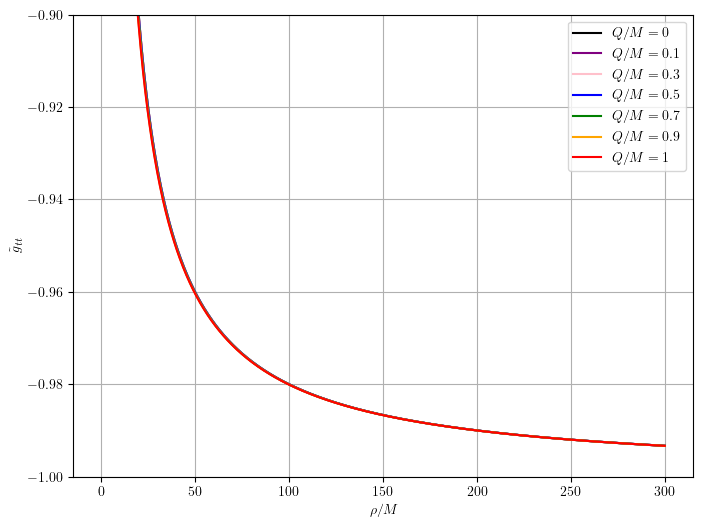

In [5]:
# Checks asymptotical behavior

plt.figure(figsize=(8, 6))

rho_array = np.linspace(0, 300, 1000)

for q, c in cases:
    r_array = np.array([r_coord(rho, q) for rho in rho_array])
    g_tt = gtt(r_array, q)
    rp, _ = rpm_ER(q)
    plt.plot(rho_array, g_tt, label=rf"$Q/M = {q}$", color=c)
    plt.plot([rho_ER(rp, q), rho_ER(rp, q)],[-bound, bound], color=c, linestyle='--')

plt.xlabel(r"$\rho / M$")
plt.ylabel(r"$\tilde g_{tt}$")

plt.ylim(-1,-0.9)

plt.grid()
plt.legend()